# Exploratory Data Analysis - E-Commerce Project

## 📌 Executive Summary

This exploratory analysis investigates customer behavior and retention in the e-commerce dataset. The analysis reveals that retention is largely a function of **actual purchasing behavior** rather than engagement, satisfaction, or tenure. Key insights include:

* **Retention is tied to repeat purchasing patterns**: Retained customers tend to have higher total order counts and monetary contribution, while engagement metrics (session duration, pages viewed, ratings, delivery times, and account lifetime) show little difference.

* **Revenue and retention align**: High-value customers are often frequent buyers, indicating that monetary contribution and retention are closely linked.

* **Category-level trends**: Certain product categories, such as Electronics, generate higher revenue per order, while categories like Fashion and Home & Garden drive more frequent repeat purchases.

* **Device preferences**: Mobile users account for the largest share of transactions, suggesting mobile optimization is important for retention-focused strategies.

* **Behavioral patterns over engagement**: Retention reflects actual purchase behavior, not customer satisfaction or site engagement metrics.

* **Strategic implication**: Business efforts should focus on encouraging repeat purchases, nurturing mid-frequency segments, and leveraging high-value categories, rather than relying primarily on engagement or peripheral metrics like session duration or delivery time.

To conclude, retention is in this dataset explained mostly by purchase frequency and revenue, but not explained by engagement (session duration and pages viewed), customer ratings, delivery time, recency and customer lifetime. This means that retention is a behavioral purchasing pattern, not an engagement or satisfaction-driven outcome, which aligns with the observation that RFM frequency/monetary explains it best. This insight tells the business that, to improve retention, focus on converting occasional buyers into repeat buyers and nurturing mid-frequency customers — rather than investing primarily in site engagement or delivery improvements.



### 📝 **Notebook Goal**

This notebook has two main parts:
1. **EDA for transaction level dataset**: The goal for transaction dataset is to understand customer purchasing behavior, product patterns, and other trends without considering retention yet.
2. **EDA for customer level retention dataset**: The goal for customer dataset is to find out how the customers differ from one another with respect to their purchasing behaviour and engagement. Also, another task is to investigate the relationship between features and the target variable (retention), and to identify top behavioral and monetary features that differentiate retained vs non-retained customers in the dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

In [2]:
# Display all columns
pd.set_option('display.max_columns', None)

In [3]:
# Load the datasets
ecommerce_data = pd.read_csv("data/cleaned/ecommerce_customer_behavior_dataset_cleaned.csv")
retention_data = pd.read_csv("data/cleaned/customer_retention_modeling_dataset.csv")
ecommerce_data

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Year,Month,Quarter,Weekday,Weekday_Name,Month_Name,Discount_Rate,Is_Weekend,First_Purchase_Date,Six_Months_Window
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4,2023,5,2,0,Monday,May,0.000000,False,2023-05-29,2023-11-29
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2,2023,10,4,3,Thursday,October,0.214230,False,2023-05-29,2023-11-29
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4,2023,12,4,1,Tuesday,December,0.000000,False,2023-05-29,2023-11-29
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4,2023,5,2,3,Thursday,May,0.205051,False,2023-02-27,2023-08-27
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4,2023,6,2,4,Friday,June,0.000000,False,2023-02-27,2023-08-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22044,ORD_001048,CUST_01048,2024-03-26,18,Female,Izmir,Beauty,130.35,1,27.30,103.05,Bank Transfer,Mobile,17,10,False,9,1,2024,3,1,1,Tuesday,March,0.209436,False,2023-02-05,2023-08-05
22045,ORD_001051,CUST_01051,2024-03-26,27,Male,Adana,Beauty,71.55,1,0.00,71.55,Debit Card,Mobile,13,9,True,6,4,2024,3,1,1,Tuesday,March,0.000000,False,2023-01-26,2023-07-26
22046,ORD_003543,CUST_03543,2024-03-26,45,Female,Antalya,Food,39.38,1,5.27,34.11,Digital Wallet,Mobile,38,10,True,5,4,2024,3,1,1,Tuesday,March,0.133824,False,2023-01-11,2023-07-11
22047,ORD_004443,CUST_04443,2024-03-26,41,Female,Istanbul,Fashion,171.19,1,0.00,171.19,Credit Card,Mobile,20,12,True,5,4,2024,3,1,1,Tuesday,March,0.000000,False,2023-05-07,2023-11-07


## Transaction Level - Exploratory Data Analysis

In this section, I will focus on the cleaned ecommerce dataset and explore distributions of data, temporal trends, the correlation of variables. For this exploration, plots such as histograms and countplots will be used, analysis such as correlation matrix will be computed.

### Check the Distributions of Data

In [4]:
ecommerce_data.describe()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating,Year,Month,Quarter,Weekday,Discount_Rate
count,22049.000000,22049.000000,22049.000000,22049.000000,22049.000000,22049.000000,22049.000000,22049.000000,22049.000000,22049.000000,22049.000000,22049.000000,22049.000000,22049.000000
mean,34.965441,449.700508,2.831920,59.598256,1210.694234,14.544197,8.998821,6.502109,3.900177,2023.190122,5.701211,2.239331,3.019411,0.047265
std,11.054313,720.091114,1.451207,216.621317,2265.755590,4.862567,2.394224,3.483322,1.128719,0.392406,3.619234,1.170398,2.007398,0.071260
min,18.000000,5.050000,1.000000,0.000000,6.210000,1.000000,1.000000,1.000000,1.000000,2023.000000,1.000000,1.000000,0.000000,0.000000
25%,27.000000,74.050000,1.000000,0.000000,159.800000,12.000000,7.000000,4.000000,3.000000,2023.000000,2.000000,1.000000,1.000000,0.000000
50%,35.000000,177.110000,3.000000,0.000000,429.920000,14.000000,9.000000,6.000000,4.000000,2023.000000,5.000000,2.000000,3.000000,0.000000
75%,42.000000,499.360000,4.000000,25.080000,1199.060000,17.000000,11.000000,8.000000,5.000000,2023.000000,9.000000,3.000000,5.000000,0.093317
max,75.000000,7900.010000,5.000000,6538.290000,37852.050000,73.000000,24.000000,25.000000,5.000000,2024.000000,12.000000,4.000000,6.000000,0.299349


Summary of the data was given in the previous notebook, `01_ecommerce_data_preparation.ipynb`, and it can be seen in the dataframe above.

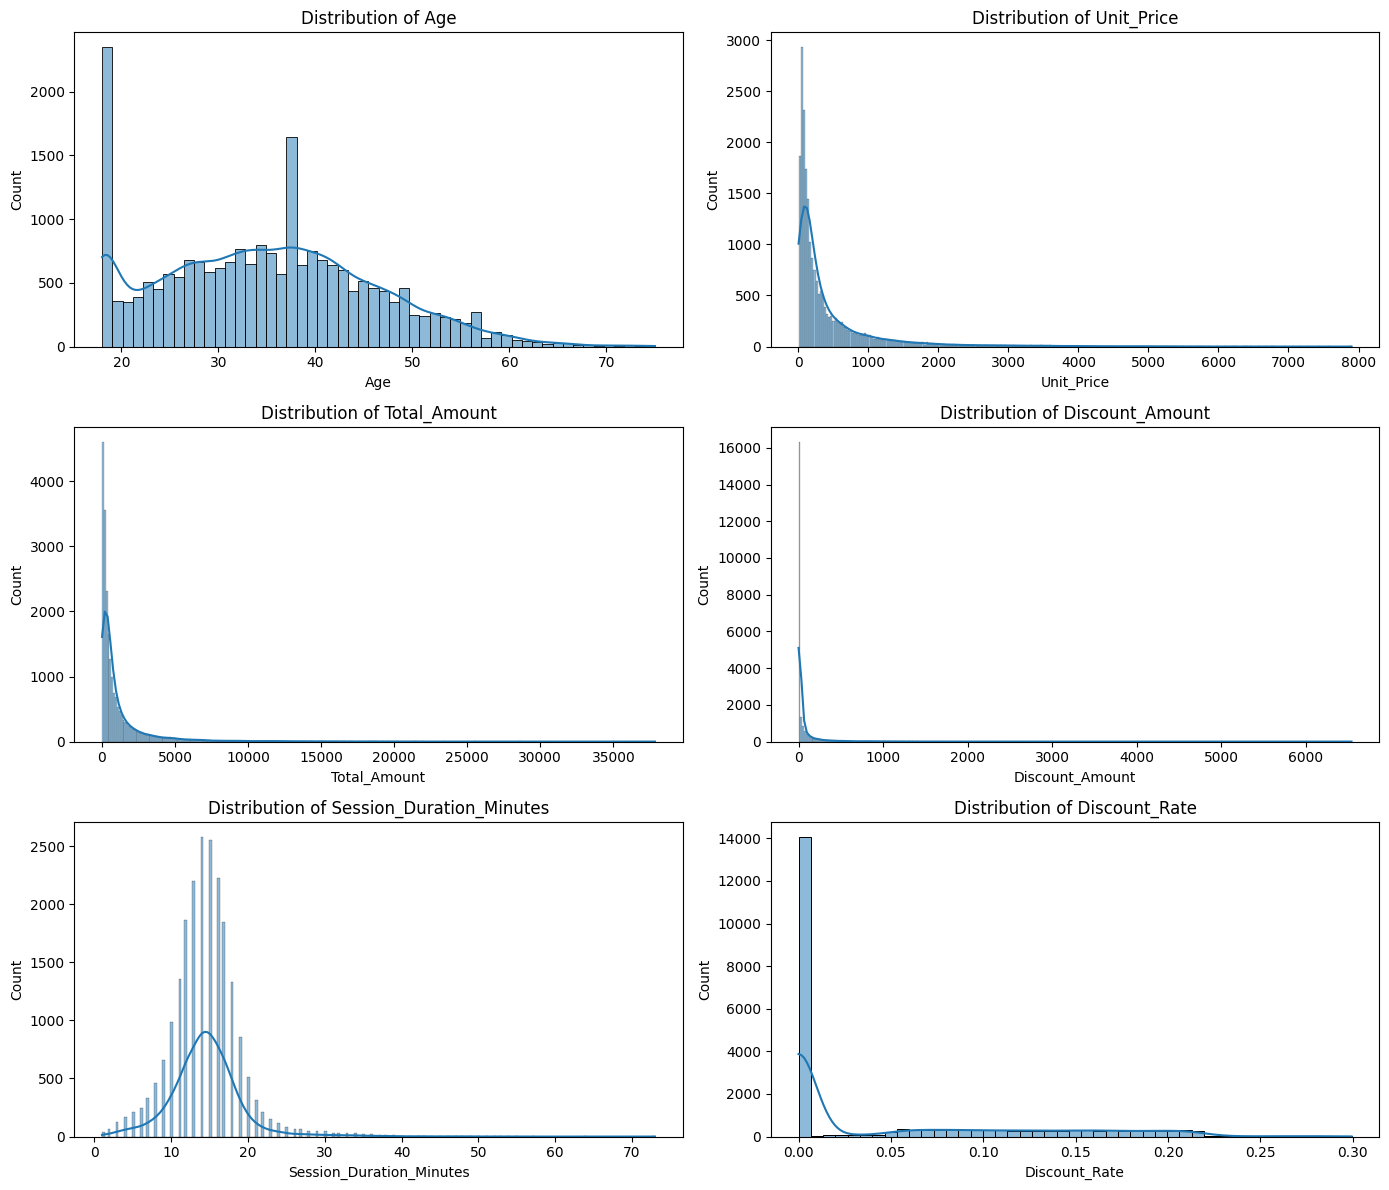

In [5]:
def plot_histograms(df, columns, n_cols=2, kde=True, figsize_scale=4):
    n_rows = math.ceil(len(columns) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, figsize_scale * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        sns.histplot(df[col], kde=kde, ax=axes[i])
        axes[i].set_title(f"Distribution of {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
    
    # Remove empty axes
    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

cols_for_histplot = [
    'Age', 'Unit_Price', 'Total_Amount',
    'Discount_Amount', 'Session_Duration_Minutes', 'Discount_Rate'
]

plot_histograms(ecommerce_data, cols_for_histplot)

From the histograms the following can be concluded:
* The age distribution is not normal, and a disproportionately large number of transactions are made by 18-year-olds (over 2,000 transactions), representing a dominant peak in the distribution. Beyond this strong concentration at age 18, transaction volume remains relatively high and stable across the 27–42 age range, and declines steadily for older groups.
* Total amount and discount amount are heavily right-skewed as a consequence of unit price skewness: this was explored in the previous notebook, and the result is expected since there high-value purchases are rare compared to lower-value ones.
* The sessions last 14 minutes on average, with majority of sesssion between 5 and 25 minutes. There are some lasting more than 30 minutes, and should be explored further to investigate if it was accidental or intentional.
* The majority of items weren't on discount, and discounts themselves ranged from 5% to 20% pretty uniformly, with fewer orders having more than 25% percent discount. The maximum discount rate is around 30%.

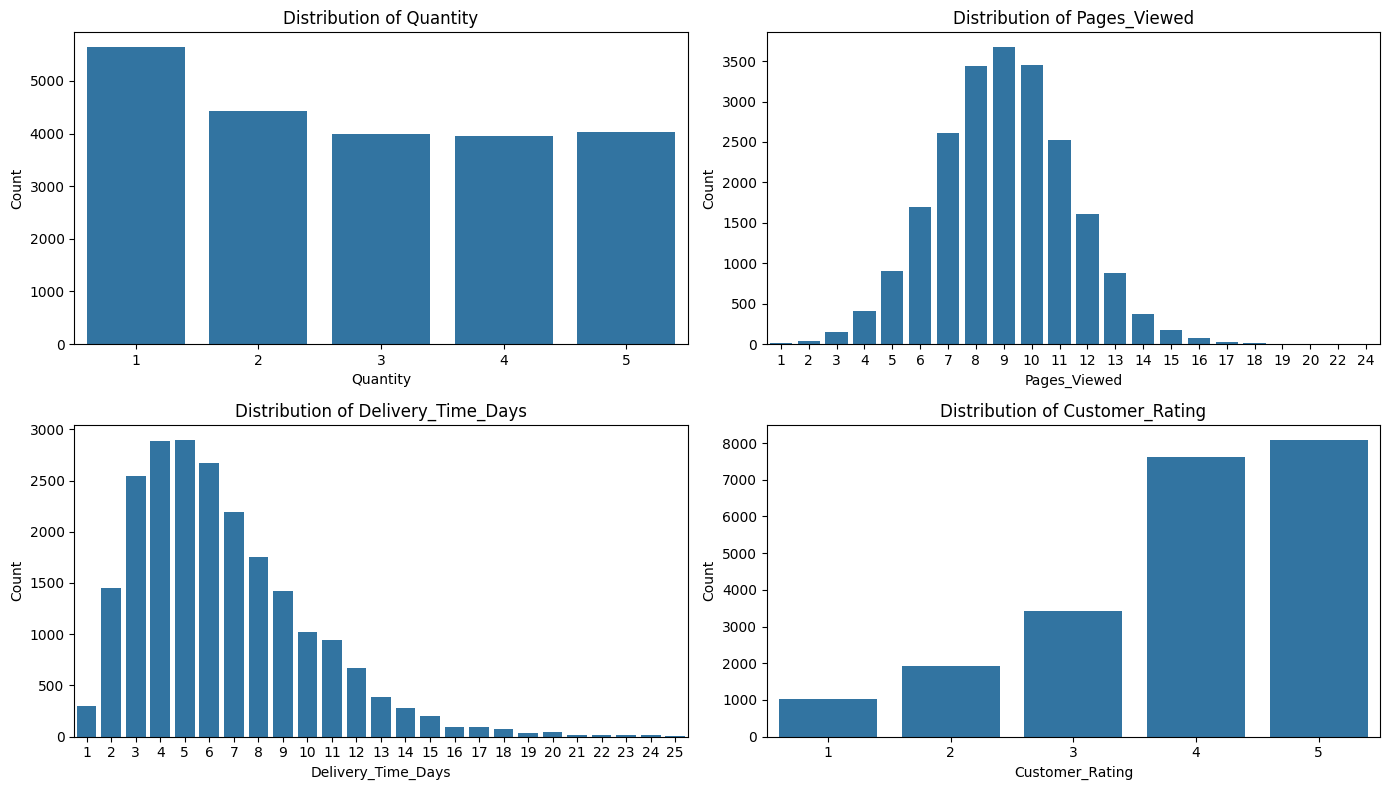

In [6]:
def plot_countplots(df, columns, n_cols=2, order_numeric=True, figsize_scale=4, rotation=0, hue=None, colors=None):
    n_rows = math.ceil(len(columns) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, figsize_scale * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        
        # Optional: automatically sort numeric ordinal columns
        if order_numeric and df[col].dtype != "object":
            order = sorted(df[col].dropna().unique())
        else:
            order = None
        
        sns.countplot(data=df, x=col, order=order, ax=axes[i], hue=hue, palette=colors)
        axes[i].set_title(f"Distribution of {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
        
        # Rotate x-axis labels
        axes[i].tick_params(axis='x', rotation=rotation)
    
    # Remove empty axes
    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

# Select numerical columns for the countplot
numerical_cols_for_countplot = ['Quantity', 'Pages_Viewed', 'Delivery_Time_Days',	'Customer_Rating']

# Use the function to plot
plot_countplots(ecommerce_data, numerical_cols_for_countplot)

From the countplot for numerical variables, the following can be noticed:
* Most individual orders have just 1 item placed, about 5500 orders, while there are around 4000 orders for each placed order from 2 to 5 items. 
* Distribution of pages viewed while order placement is normal (Gaussian), averaging at 9 pages.
* Most deliveries are done between 2 and 9 days, and the delivery time distribution is right-skewed.
* The vast majority of customers gave a rating of 4 and 5, while ratings such as 3, 2, and 1 are given much less.

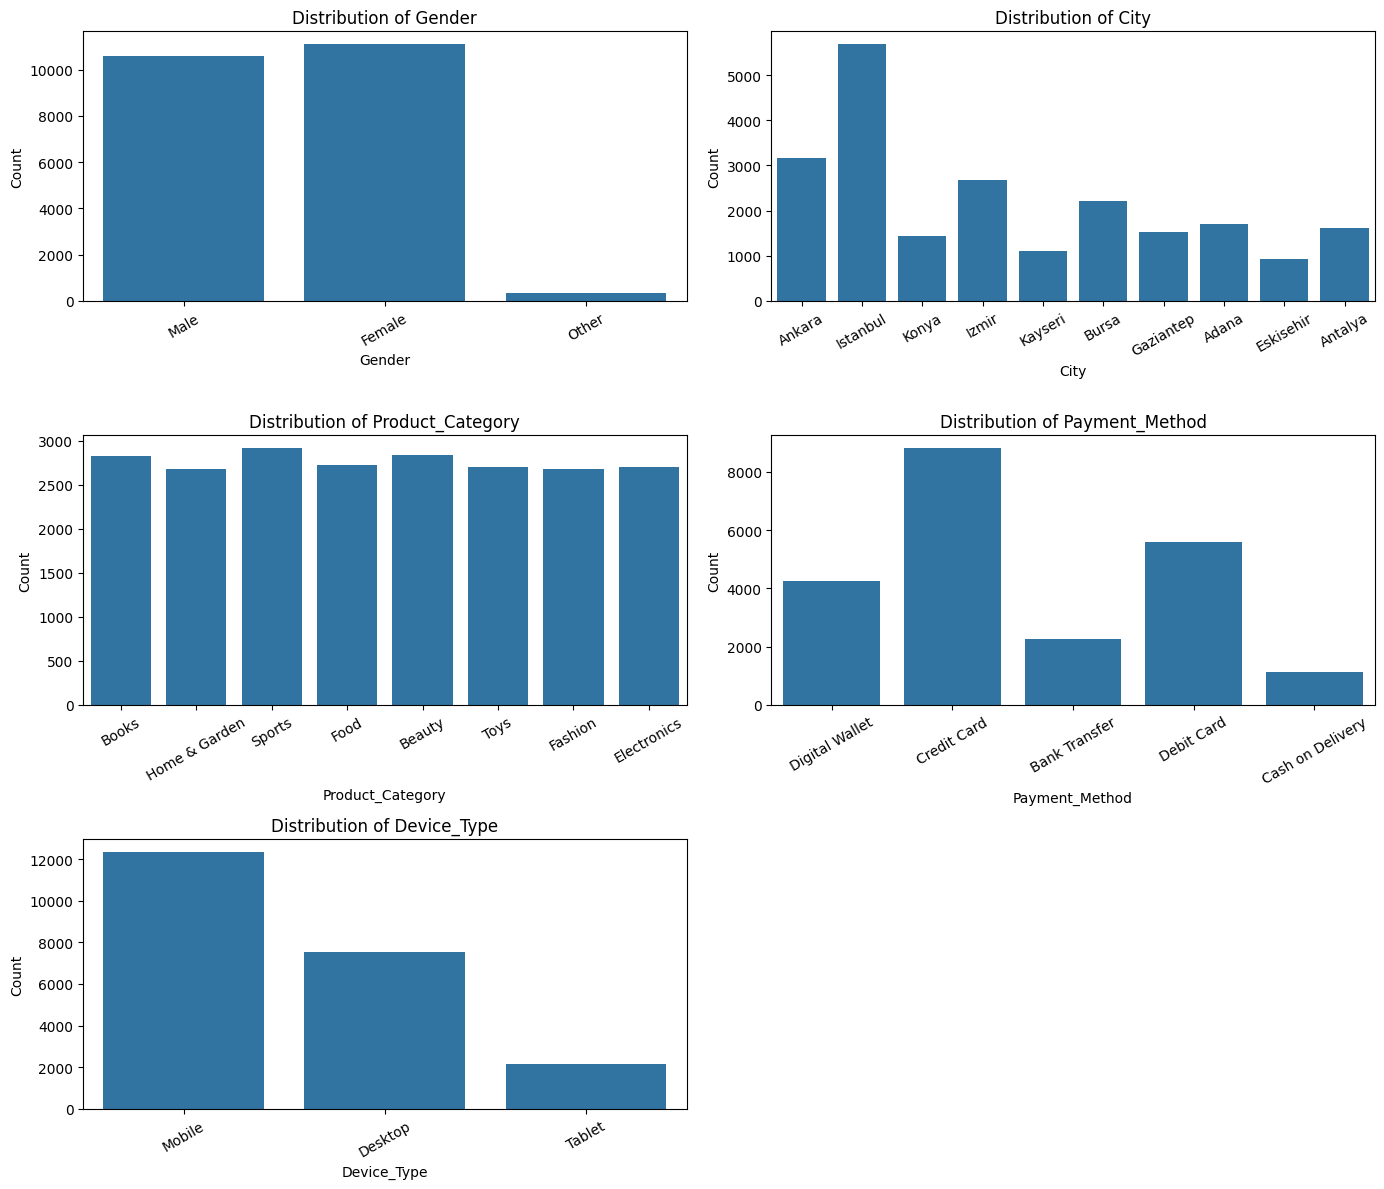

In [7]:
# Select categorical columns for the countplot
categorical_cols_for_countplot = ['Gender',	'City',	'Product_Category', 'Payment_Method', 'Device_Type']

plot_countplots(ecommerce_data, categorical_cols_for_countplot, rotation = 30)

From the countplots for categorical columns the following can be concluded about column distributions:
* Males and females placed approximately the same amount of orders, 10500 orders each, while people of the 'Other' gender placed just around 500 orders, which is much less.
* The majority of customer orders are from Istanbul, with around 5800 orders, followed by Ankara and Izmir with about 4000, and other cities have less orders than that.
* All product categories are ordered approximately the same amount of times.
* Most customers paid via credit card, followed by debit card and digital wallet, while bank transfer and cash on delivery were the least utilised payment methods.
* Most customers placed their orders on their mobile, around 12000 orders, followed by 8000 on desktop and the least about 2000 on tablet.

### Temporal Trends

In this section I will plot the trends for the whole temporal range of data. I will explore **number of orders** during the given period, the **revenue**(total amount of TRY) for each month, the **average order value (AOV)** for each month.

In [8]:
# Aggregate monthly statistics 
monthly_stats = (ecommerce_data
    .groupby(['Year', 'Month', 'Month_Name'])
    .agg(
        Orders=('Order_ID', 'count'), 
        Revenue=('Total_Amount', 'sum'))
    .reset_index())

# Create a Year-Month string for x-axis labels
monthly_stats['Month_Year'] = monthly_stats['Month_Name'] + ' ' + monthly_stats['Year'].astype(str)

# Create average order value column
monthly_stats['AOV'] = monthly_stats['Revenue'] / monthly_stats['Orders']
monthly_stats['AOV'] = monthly_stats['AOV'].round(2)

monthly_stats_filtered = monthly_stats[
    ~((monthly_stats['Year'] == 2024) & (monthly_stats['Month'] == 3))
].copy()

monthly_stats_filtered = monthly_stats_filtered.sort_values(['Year', 'Month'])

In [9]:
def plot_multi_trends_with_fill(df, x, y_cols, titles=None, figsize=(12,7)):

    n = len(y_cols)
    fig, axes = plt.subplots(n, 1, figsize=figsize, sharex=True)

    if n == 1:
        axes = [axes]

    if titles is None:
        titles = y_cols

    for i, y in enumerate(y_cols):

        x_values = df[x].values
        y_values = df[y].values
        overall_mean = y_values.mean()

        axes[i].plot(x_values, y_values, marker='o')
        axes[i].axhline(overall_mean, linestyle='--', color='black')

        axes[i].fill_between(
            x_values,
            y_values,
            overall_mean,
            color = 'green',
            where=(y_values > overall_mean),
            alpha=0.2,
            interpolate = True
        )

        axes[i].fill_between(
            x_values,
            y_values,
            overall_mean,
            where=(y_values <= overall_mean),
            alpha=0.2,
            color='red',
            interpolate = True,
        )

        axes[i].set_title(titles[i])
        axes[i].set_ylabel(y)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

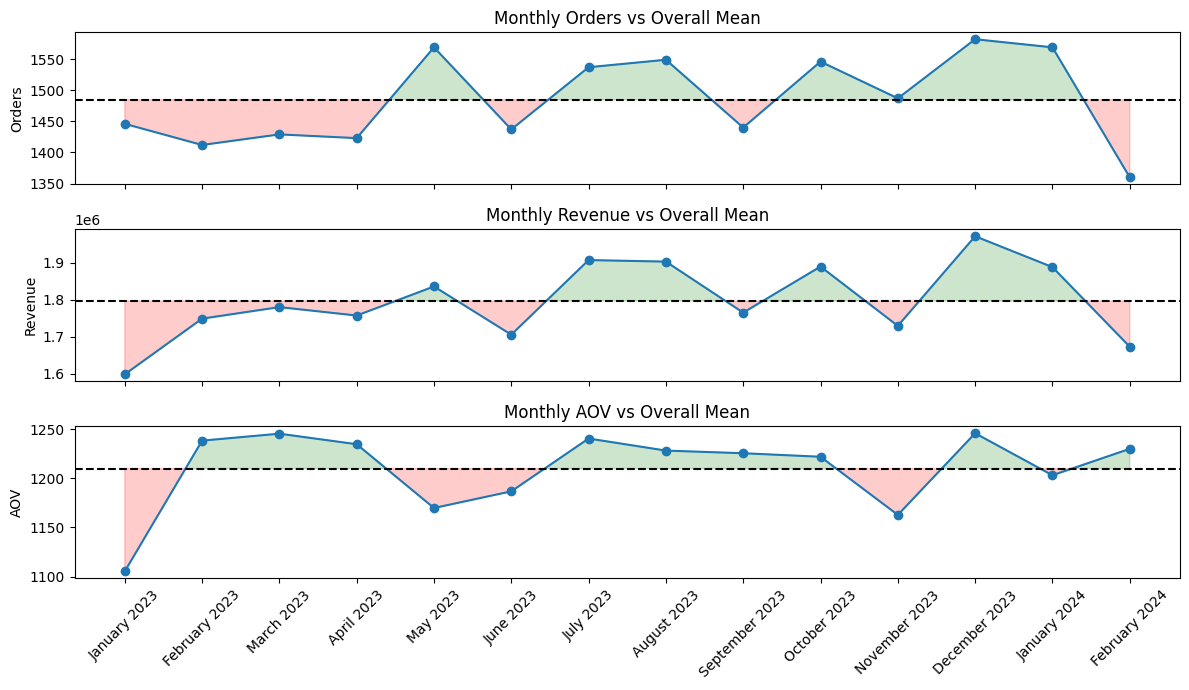

In [10]:
plot_multi_trends_with_fill(
    df=monthly_stats_filtered,
    x='Month_Year',
    y_cols=['Orders', 'Revenue', 'AOV'],
    titles=[
        'Monthly Orders vs Overall Mean',
        'Monthly Revenue vs Overall Mean',
        'Monthly AOV vs Overall Mean'
    ]
)

In [11]:
monthly_stats[['Month_Year', 'Orders', 'AOV', 'Revenue']].sort_values('Revenue', ascending=False)

,Month_Year,Orders,AOV,Revenue
11,December 2023,1582,1245.85,1970931.29
6,July 2023,1537,1240.51,1906664.17
7,August 2023,1549,1228.22,1902505.64
9,October 2023,1546,1221.95,1889133.94
12,January 2024,1569,1203.12,1887699.70
4,May 2023,1569,1169.80,1835413.64
2,March 2023,1429,1245.43,1779721.59
8,September 2023,1440,1225.53,1764767.23
3,April 2023,1423,1234.70,1756980.61
1,February 2023,1412,1238.36,1748562.21


The trends for the number of orders and revenue are generally aligned, which is expected since revenue is largely driven by order volume. Some deviations are visible: in January 2023, revenue was relatively low despite a moderate number of orders, reflecting a lower average order value (AOV). Smaller differences between order volume and revenue appear in May and November 2023. In contrast, March 2023 shows slightly higher revenue relative to the number of orders, indicating somewhat larger-than-average order values.

The highest revenue was recorded in December 2023 (1,970,931 TRY). Although March 2024 shows the lowest revenue (1,546,735 TRY), it contains only 26 days of data. Therefore, January 2023 (1,598,297 TRY) is more appropriately considered the lowest full-month revenue in the dataset.

Importantly, the AOV remains relatively stable across months (mostly within the 1,160–1,250 TRY range). This stability suggests that revenue fluctuations are primarily driven by changes in order volume rather than substantial shifts in pricing or individual order sizes.


### Correlation between variables

Correlation heatmap gives a pairwise values for linear correlation between variables. The correlation heatmap shows that `Unit_Price` has a strong positive linear relationship with Total_Amount, indicating that orders with higher unit prices tend to have higher total values. `Unit_Price` is also moderately correlated with `Discount_Amount`, and `Discount_Amount` is moderately correlated with `Discount_Rate`, which reflects how these pricing-related variables move together. As expected, `Month` and `Quarter` are highly correlated due to their calendar structure. In contrast, behavioral variables such as session duration, pages viewed, customer rating, and delivery time show very weak linear relationships with financial metrics, suggesting limited direct linear association with order value.

Hence, the relationships observed are structurally reasonable, and the dataset behaves as expected.

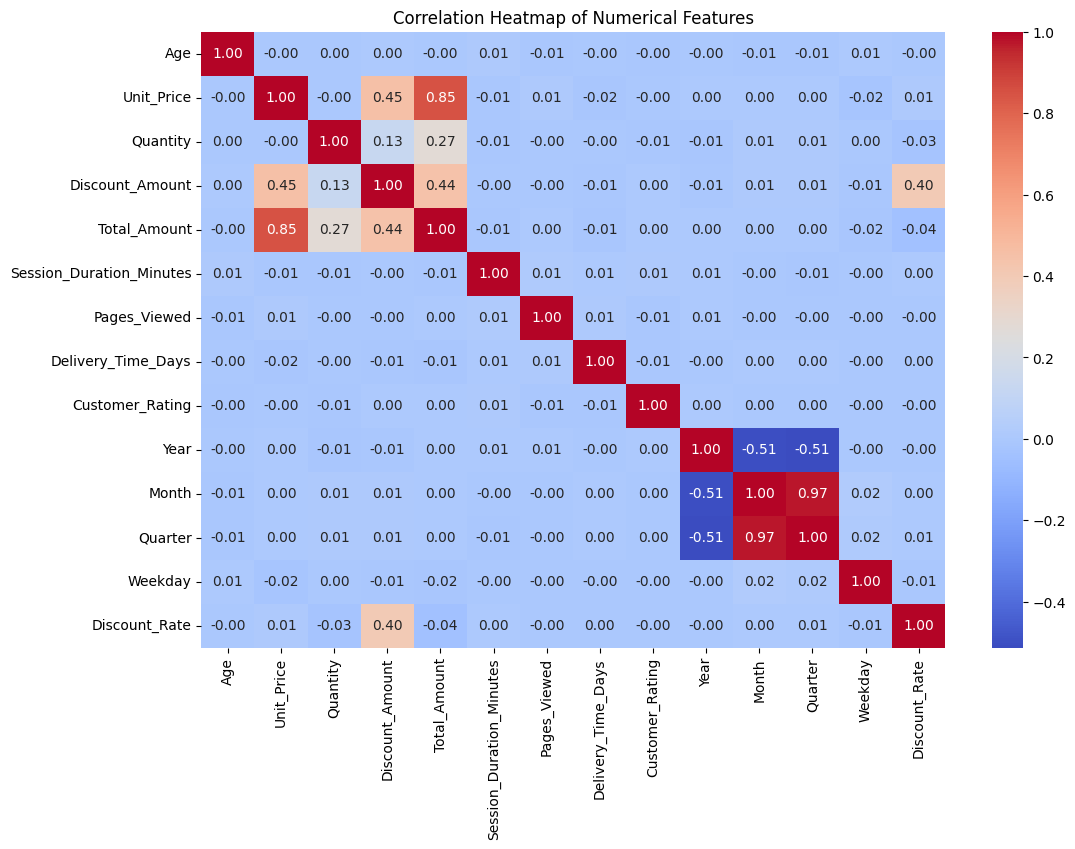

In [12]:
# Select numerical variables
numerical_vars = ecommerce_data.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = numerical_vars.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Group-Wise Trends and Relationships

In this section, I will explore how key features vary across different groups.  Understanding group-wise patterns allows me to identify which segments contribute most to revenue, order volume, or how average order value differs from group to group. This can give insights into which categories should be targeted primarily when considering marketing and retention strategies.


In [13]:
def plot_barplots(df, x, y_list, n_cols=2, hue=None, colors=None, figsize_scale=5, rotation=0):
    """
    Plot multiple barplots for the same x-axis but different y-axes.

    Parameters:
    - df: DataFrame
    - x: str, column for x-axis
    - y_list: list of columns for y-axis
    - n_cols: int, number of columns in subplot grid
    - hue: str, optional hue variable
    - colors: list, optional list of colors/palettes for each plot (len should match y_list)
    - figsize_scale: int, scaling factor for figure height
    - rotation: int, rotation for x-axis labels
    """
    
    n_rows = math.ceil(len(y_list) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, figsize_scale * n_rows))
    axes = axes.flatten()
    
    for i, y in enumerate(y_list):
        color = None
        if colors is not None and i < len(colors):
            color = colors[i]
        
        sns.barplot(data=df, x=x, y=y, hue=hue, ax=axes[i], palette=color)
        axes[i].set_title(f"{y} by {x}")
        axes[i].set_xlabel(x)
        axes[i].set_ylabel(y)
        axes[i].tick_params(axis='x', rotation=rotation)
    
    for j in range(len(y_list), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

#### Analysis by Product Category

In [14]:
# Aggregate by Product Category
category_stats = (
    ecommerce_data
    .groupby('Product_Category')
    .agg(Orders=('Order_ID', 'count'),
        Revenue=('Total_Amount', 'sum'),
        AOV=('Total_Amount', 'mean'))
    .sort_values('Revenue', ascending=False)
    .reset_index())

category_stats['Revenue_Contribution_Percentage'] = (category_stats['Revenue'] / category_stats['Revenue'].sum()).round(2)
category_stats['AOV'] = category_stats['AOV'].round(2)

category_stats

,Product_Category,Orders,Revenue,AOV,Revenue_Contribution_Percentage
0,Electronics,2698,12810704.46,4748.22,0.48
1,Home & Garden,2681,4932252.80,1839.71,0.18
2,Sports,2915,3959650.55,1358.37,0.15
3,Fashion,2678,1952250.63,729.00,0.07
4,Toys,2700,1237380.01,458.29,0.05
5,Beauty,2833,851021.76,300.40,0.03
6,Food,2722,518193.32,190.37,0.02
7,Books,2822,433143.63,153.49,0.02


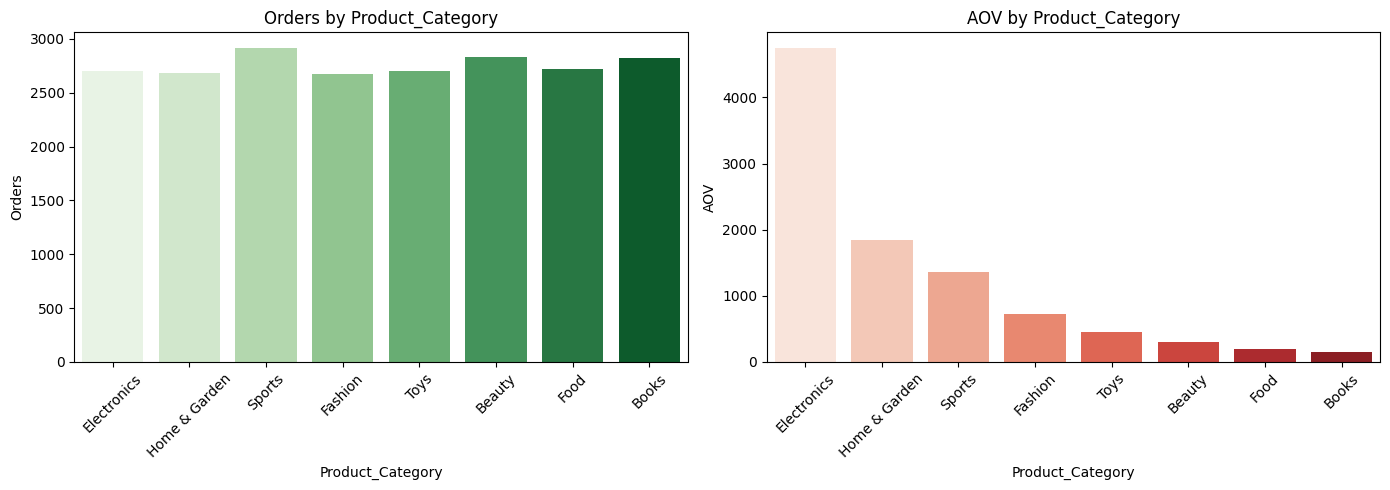

In [15]:
plot_barplots(df=category_stats,x='Product_Category',y_list=['Orders', 'AOV'], colors=['Greens', 'Reds'], hue='Product_Category', rotation=45)

From the plots above, it is apparent that even though categories are evenly ordered across the dataset, average product value is much higher for electronics than other categories, around 4500 TRY on average, leading to much higher revenue (from the table above the graphs). After electronics, Home and Garden and Sports average at about 2000 and 1500 TRY respectively, while all other categories have average value orders at less than 1000 TRY. 

This large difference in average value of orders explains this large difference in revenue across categories. Revenue differences are therefore primarily price-driven rather than volume-driven. Electronics dominates total revenue despite having a similar number of transactions, highlighting its disproportionate impact on overall business performance.

#### Analysis by City

In [16]:
city_stats = (ecommerce_data
    .groupby('City')
    .agg(Orders=('Order_ID', 'count'),
        Revenue=('Total_Amount', 'sum'),
        AOV=('Total_Amount', 'mean'))
    .sort_values('Revenue', ascending=False)
    .reset_index())
city_stats['AOV'] = city_stats['AOV'].round(2)

city_stats

,City,Orders,Revenue,AOV
0,Istanbul,5686,6980718.34,1227.70
1,Ankara,3157,3709978.92,1175.16
2,Izmir,2672,3219278.59,1204.82
3,Bursa,2217,2776104.41,1252.19
4,Antalya,1620,1977144.04,1220.46
5,Adana,1704,1939379.82,1138.13
6,Gaziantep,1532,1891830.66,1234.88
7,Konya,1437,1708127.74,1188.68
8,Kayseri,1108,1403962.44,1267.11
9,Eskisehir,916,1088072.20,1187.85


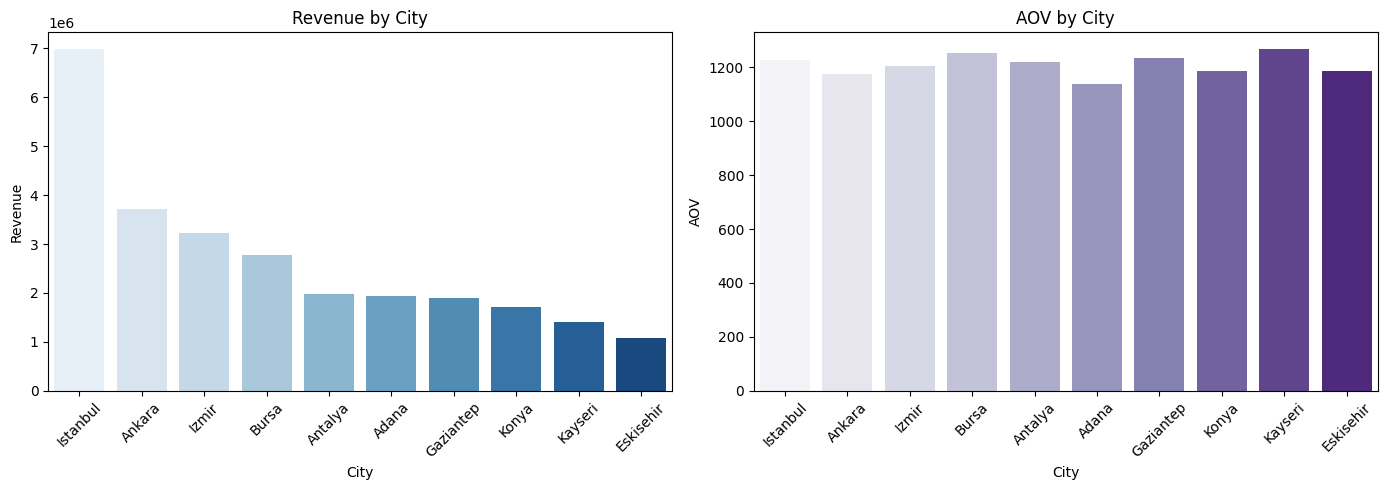

In [17]:
plot_barplots(df=city_stats,x='City', y_list=['Revenue', 'AOV'], rotation=45, colors=['Blues', 'Purples'], hue='City')

#### 

From the dataframe `city_stats` it can be seen that Istanbul is the city with the largest volme of orders by far, followed by Ankara, Izmir and Bursa, and then all others. Average order values are fairly consistent across all cities (~1,140–1,270 TRY), indicating that customer spending per order does not vary substantially geographically. Hence, revenue across cities is largely driven by order volume rather than average order value. Istanbul contributes the most revenue (≈ 7M TRY) due to its high number of orders, while smaller cities like Kayseri and Eskisehir contribute the least.

These insights suggest that marketing and retention strategies should prioritize high-volume cities, while opportunities in smaller cities could focus on increasing order frequency. In essence, this means to focus on keeping customers in high-volume cities, and focus on getting more customers in smaller cities.

#### Analysis by Discount Rate

In [18]:
# Create discount buckets
bins = [-0.01, 0, 0.10, 0.20, 0.30]
labels = ['No Discount', '0-10%', '10-20%', '20-30%']

# Split the data into bins (buckets)
ecommerce_data['Discount_Bucket'] = pd.cut(ecommerce_data['Discount_Rate'],bins=bins,labels=labels)

# Construct a dataframe
discount_stats = (ecommerce_data
    .groupby('Discount_Bucket', observed=True)
    .agg(Orders=('Order_ID', 'count'),
        Revenue=('Total_Amount', 'sum'),
        AOV=('Total_Amount', 'mean'),
        Avg_Quantity=('Quantity', 'mean'))
    .reset_index())

discount_stats['Avg_Quantity'] = discount_stats['Avg_Quantity'].round(2)
discount_stats['AOV'] = discount_stats['AOV'].round(2)

discount_stats

,Discount_Bucket,Orders,Revenue,AOV,Avg_Quantity
0,No Discount,14046,17566883.52,1250.67,2.82
1,0-10%,2778,3623143.71,1304.23,3.03
2,10-20%,4191,4512235.19,1076.65,2.84
3,20-30%,1034,992334.74,959.70,2.50


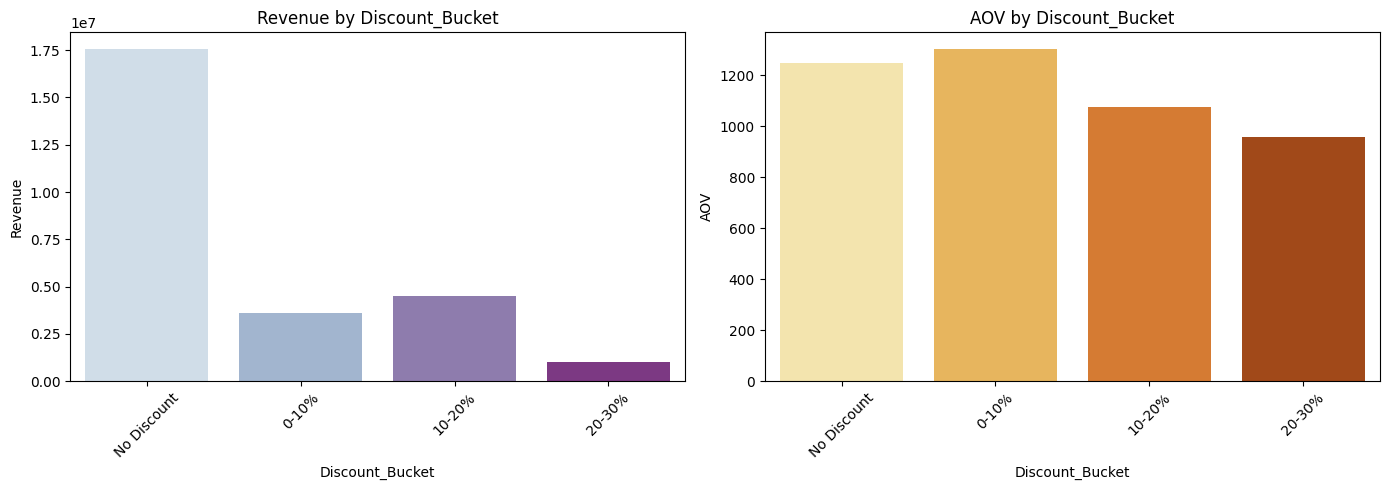

In [19]:
plot_barplots(df=discount_stats,x='Discount_Bucket', y_list=['Revenue', 'AOV'], rotation=45, colors=['BuPu', 'YlOrBr'], hue='Discount_Bucket')

The majority of orders are placed without any discounts, and these full-price purchases contribute the largest share of revenue. Interestingly, small discounts (0–10%) are associated with the highest average order value (≈1,304 TRY), slightly above both non-discounted orders and other discounted orders.

However, in terms of volume, orders with 10–20% discounts occur 1.5 times more frequently than 0–10% discounted orders, generating more total revenue within this bucket despite a lower AOV. Larger discounts (20–30%) are less common and correlate with smaller average order values and lower quantities, suggesting these are applied mostly to low-value or clearance items.

Overall, while small and moderate discounts have some impact on purchase behavior, revenue is primarily driven by full-price orders, not discount-driven sales.

In addition, average order value does not change substantially across different discount buckets or product categories, indicating that larger discounts do not systematically drive bigger orders for any specific category.

#### Analysis by Session Duration (in minutes)

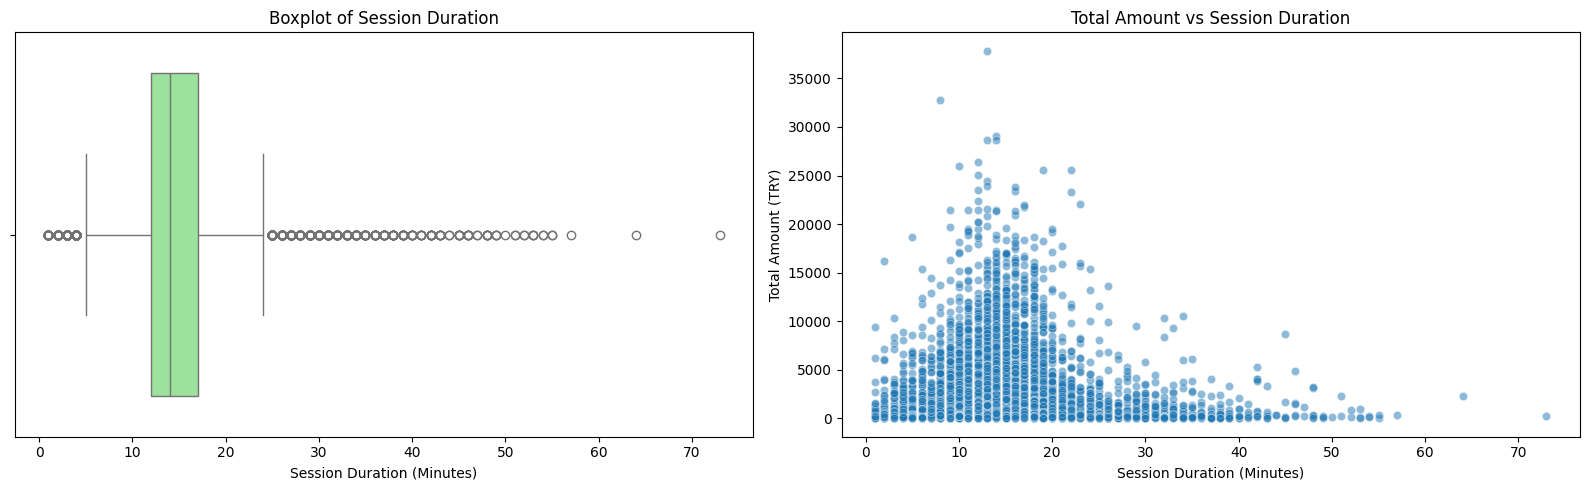

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

sns.boxplot(x=ecommerce_data['Session_Duration_Minutes'], color='lightgreen', ax=axes[0])
axes[0].set_title("Boxplot of Session Duration")
axes[0].set_xlabel("Session Duration (Minutes)")

sns.scatterplot(data=ecommerce_data, x='Session_Duration_Minutes', y='Total_Amount', alpha=0.5, ax=axes[1])
axes[1].set_title("Total Amount vs Session Duration")
axes[1].set_xlabel("Session Duration (Minutes)")
axes[1].set_ylabel("Total Amount (TRY)")

plt.tight_layout()
plt.show()

From the plots above, it is apparent that most sessions last between 10 and 20 minutes, while durations shorter than 5 minutes or longer than 25 minutes are relatively rare and can be considered outliers. Interestingly, longer session durations do not correspond to higher spending — high-value purchases are typically made within the 10–20 minute range, suggesting that prolonged browsing is not correlated with higher-value orders.

#### Analysis by Device Type

In [21]:
device_stats = (
    ecommerce_data
    .groupby('Device_Type', observed=True)
    .agg(Orders=('Order_ID', 'count'),
         Revenue=('Total_Amount', 'sum'),
         AOV=('Total_Amount', 'mean'))
    .reset_index()
)

device_stats

,Device_Type,Orders,Revenue,AOV
0,Desktop,7556,9311540.85,1232.337328
1,Mobile,12338,14839153.93,1202.719560
2,Tablet,2155,2543902.38,1180.465142


When examining orders by device type, the majority of transactions were placed via mobile devices (12,300 orders), followed by desktop (7,500) and tablet (2,150). Average order values are fairly similar across devices (≈1,180–1,230 TRY), indicating that customer spending per order is not strongly influenced by device choice. This suggests that the device primarily affects order volume, not order value.

#### Analysis by Payment Method

In [22]:
payment_stats = (
    ecommerce_data
    .groupby('Payment_Method', observed=True)
    .agg(Orders=('Order_ID', 'count'),
         Revenue=('Total_Amount', 'sum'),
         AOV=('Total_Amount', 'mean'))
    .reset_index()
)

payment_stats

,Payment_Method,Orders,Revenue,AOV
0,Bank Transfer,2273,2862371.42,1259.292310
1,Cash on Delivery,1136,1288256.17,1134.028319
2,Credit Card,8813,10986385.03,1246.611260
3,Debit Card,5586,6402685.56,1146.202213
4,Digital Wallet,4241,5154898.98,1215.491389


Average order value is similar across all payment methods. The largest amount of revenue is generated by customers using credit cards for payment, while the least is generated by cash on delivery payments, and this is proportional to the number of orders per payment method. Hence, the total revenue is primarily driven by order volume, not differences in AOV, since the average order value is fairly similar across all payment methods (approx. 1,130–1,260 TRY).

#### Analysis by Returning Customer

In [23]:
loyalty_stats = ecommerce_data.groupby('Is_Returning_Customer').agg(
    Orders=('Order_ID','count'),
    Revenue=('Total_Amount','sum'),
    AOV=('Total_Amount','mean')
).reset_index()

loyalty_stats['AOV'] = loyalty_stats['AOV'].round(2)

loyalty_stats

,Is_Returning_Customer,Orders,Revenue,AOV
0,False,4020,4555855.86,1133.30
1,True,18029,22138741.30,1227.95


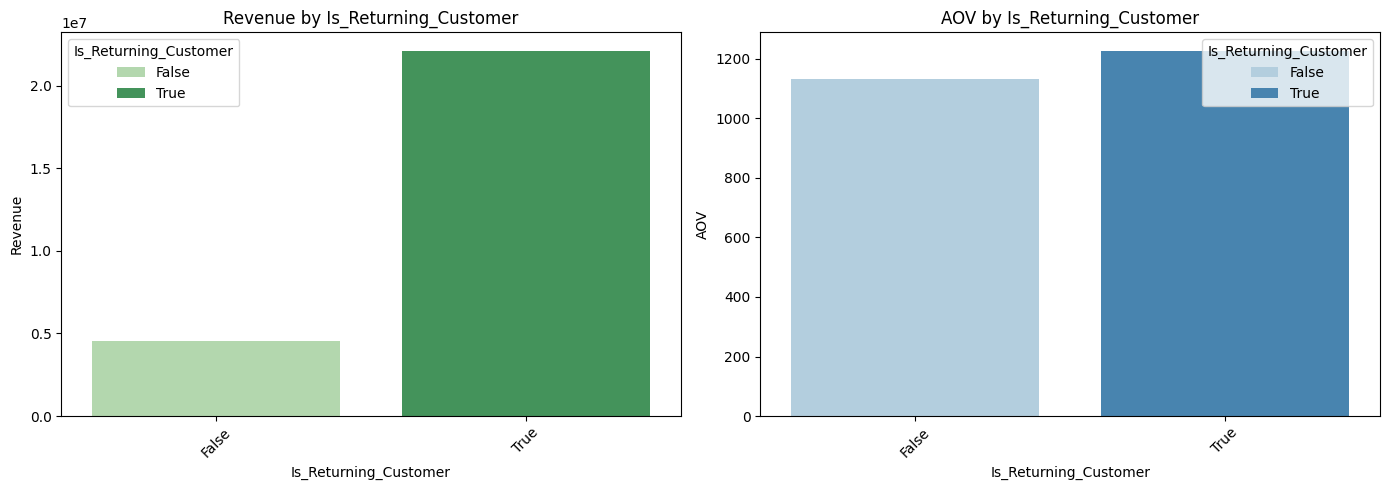

In [24]:
plot_barplots(df=loyalty_stats,x='Is_Returning_Customer', y_list=['Revenue', 'AOV'], rotation=45, colors=['Greens', 'Blues'], hue='Is_Returning_Customer')

Non-returning customers are a smaller fraction of total customers, meaning that returning customers drive the majority of revenue. The slight increase in AOV for returning customers suggests they may be more comfortable purchasing higher-value items, but the difference in AOV is rather small.

Therefore, marketing, loyalty programs, and promotions should prioritize keeping customers coming back, so retention strategies should be a priority when considering business improvements.

## Customer Level - Exploratory Data Analysis

In this section, I will analyze the dataset from the customer perspective, rather than the transaction perspective. The goal is to understand patterns in customer behavior, including frequency, spending, retention, and loyalty, which can inform marketing and retention strategies. This section should answer the following questions:

* How different are customers?
* Who drives revenue?
* How long do customers stay active?
* How engaged are customers on average?
* How does retention relate to customer behavior and lifetime value?

Retention is defined in the previous notebook as `Retention = 1` if a customer placed ≥3 orders within 6 months, and 0 otherwise.

In [25]:
customer_stats = ecommerce_data.groupby('Customer_ID').agg(
    Total_Num_Orders=('Order_ID', 'count'),
    Revenue=('Total_Amount', 'sum'),
    AOV=('Total_Amount', 'mean'),
    First_Purchase_Date=('Date', 'min'),
    Last_Purchase_Date=('Date', 'max'),
    Avg_Session_Duration_Minutes=('Session_Duration_Minutes','mean'),
    Avg_Pages_Viewed=('Pages_Viewed','mean'),
    Avg_Customer_Rating=('Customer_Rating','mean'),
    Avg_Delivery_Time_Days=('Delivery_Time_Days','mean'),
    Is_Returning_Customer=('Is_Returning_Customer','max'),
    Most_Purchased_Category=('Product_Category', lambda x: x.value_counts().idxmax()),
    Most_Used_Device=('Device_Type', lambda x: x.value_counts().idxmax()),
    Most_Used_Payment=('Payment_Method', lambda x: x.value_counts().idxmax()),
    Avg_Discount_Rate=('Discount_Rate', 'mean'),
).round(2).reset_index()

customer_stats['Is_Returning_Customer'] = customer_stats['Is_Returning_Customer'].astype(int)
customer_stats

,Customer_ID,Total_Num_Orders,Revenue,AOV,First_Purchase_Date,Last_Purchase_Date,Avg_Session_Duration_Minutes,Avg_Pages_Viewed,Avg_Customer_Rating,Avg_Delivery_Time_Days,Is_Returning_Customer,Most_Purchased_Category,Most_Used_Device,Most_Used_Payment,Avg_Discount_Rate
0,CUST_00001,4,2418.95,604.74,2023-05-29,2023-12-05,12.75,9.00,3.50,9.0,1,Books,Mobile,Credit Card,0.05
1,CUST_00002,3,1142.24,380.75,2023-02-27,2023-06-16,11.00,9.33,4.33,6.0,1,Food,Mobile,Digital Wallet,0.07
2,CUST_00003,3,3097.25,1032.42,2023-01-13,2024-01-03,10.00,7.33,4.00,5.0,1,Toys,Desktop,Credit Card,0.00
3,CUST_00004,2,495.87,247.94,2024-01-15,2024-02-13,12.50,10.50,4.50,4.5,0,Fashion,Desktop,Credit Card,0.10
4,CUST_00005,4,2772.18,693.04,2023-03-16,2023-06-21,12.75,8.75,3.50,5.0,1,Home & Garden,Mobile,Bank Transfer,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST_04996,5,3131.33,626.27,2023-07-07,2024-02-22,13.60,7.40,3.40,7.6,1,Sports,Mobile,Bank Transfer,0.02
4996,CUST_04997,5,18101.09,3620.22,2023-01-31,2024-03-13,16.20,10.40,4.00,7.0,1,Sports,Mobile,Debit Card,0.02
4997,CUST_04998,2,533.94,266.97,2023-04-27,2023-08-20,11.50,7.00,3.00,8.0,0,Toys,Desktop,Credit Card,0.00
4998,CUST_04999,2,6174.00,3087.00,2023-10-12,2024-01-16,10.50,14.00,3.00,6.5,0,Beauty,Mobile,Digital Wallet,0.00


In the cell above the data is grouped on customer ID's and aggregated, so that each row represents one customer. New features are created, such as the total number of orders per customer, the average order value for each customer, revenue (total amount the customer spent on all purchases in the data), averages of columns, **recency days** (number of days since the last purchase) and **customer lifetime days** (total amount of time between the first and the last purchase).

Another important retention  metric is **RFM (Recency, Frequency, Monetary)**, which segments customers based on purchasing behavior to improve loyalty and lifetime value. 

* **Recency (R)**: Measures how recently a customer purchased. Lower values (more recent) indicate higher engagement and better retention probability.
* **Frequency (F)**: Measures how often a customer buys, identifying loyal, repeat customers.
* **Monetary Value (M)**: Measures how much a customer spends, used to identify VIPs

The data for RFM is split into 3 bins (approximately 33% for each bin, in terms of quantiles). 

The RFM score distribution shows a balanced customer base across low, mid, and high segments. Customers with low RFM scores (3–4) are likely inactive, infrequent buyers with low spending, making them potential churn risks. The mid-range segment (5–7) represents the largest group and consists of moderately active customers with average frequency and revenue — this segment offers strong growth potential if engagement strategies are applied effectively. Finally, customers with high RFM scores (8–9) are recent, frequent, and high-spending buyers, representing the loyal and high-value segment that should be prioritized for retention and loyalty initiatives.

In [26]:
# Create customer features
def add_customer_features(customer_df, date_col_last, date_col_first,
                              orders_col='Total_Num_Orders',
                              revenue_col='Revenue',
                              n_bins=3):
    """
    Adds Recency, Lifetime, and RFM features to a customer-level dataframe.
    
    Parameters:
    - customer_df: aggregated customer dataframe
    - date_col_last: column name for last purchase date
    - date_col_first: column name for first purchase date
    - orders_col: total number of orders column
    - revenue_col: revenue column
    - n_bins: number of quantile bins for RFM (default=3)
    
    Returns:
    - customer_df with added features
    """
    
    df = customer_df.copy()
    
    reference_date = pd.to_datetime(df[date_col_last]).max()
    
    # Add recency days and customer lifetime days
    df['Recency_Days'] = (reference_date - pd.to_datetime(df[date_col_last])).dt.days
    df['Customer_Lifetime_Days'] = (pd.to_datetime(df[date_col_last]) - pd.to_datetime(df[date_col_first])).dt.days
    
    # RFM quantiles
    df['R_score'] = pd.qcut(df['Recency_Days'], n_bins, labels=list(range(n_bins, 0, -1)))
    df['F_score'] = pd.qcut(df[orders_col], n_bins, labels=list(range(1, n_bins + 1)))
    df['M_score'] = pd.qcut(df[revenue_col], n_bins, labels=list(range(1, n_bins + 1)))
    
    # RFM segment and score
    df['RFM_Segment'] = (df['R_score'].astype(str) + df['F_score'].astype(str) + df['M_score'].astype(str))
    df['RFM_Score'] = (df['R_score'].astype(int) + df['F_score'].astype(int) + df['M_score'].astype(int))
    
    return df

# Apply function
customer_stats = add_customer_features(customer_stats,
                                        date_col_last='Last_Purchase_Date',
                                        date_col_first='First_Purchase_Date',
                                        n_bins=3)

customer_stats

,Customer_ID,Total_Num_Orders,Revenue,AOV,First_Purchase_Date,Last_Purchase_Date,Avg_Session_Duration_Minutes,Avg_Pages_Viewed,Avg_Customer_Rating,Avg_Delivery_Time_Days,Is_Returning_Customer,Most_Purchased_Category,Most_Used_Device,Most_Used_Payment,Avg_Discount_Rate,Recency_Days,Customer_Lifetime_Days,R_score,F_score,M_score,RFM_Segment,RFM_Score
0,CUST_00001,4,2418.95,604.74,2023-05-29,2023-12-05,12.75,9.00,3.50,9.0,1,Books,Mobile,Credit Card,0.05,112,190,1,2,2,122,5
1,CUST_00002,3,1142.24,380.75,2023-02-27,2023-06-16,11.00,9.33,4.33,6.0,1,Food,Mobile,Digital Wallet,0.07,284,109,1,1,1,111,3
2,CUST_00003,3,3097.25,1032.42,2023-01-13,2024-01-03,10.00,7.33,4.00,5.0,1,Toys,Desktop,Credit Card,0.00,83,355,2,1,2,212,5
3,CUST_00004,2,495.87,247.94,2024-01-15,2024-02-13,12.50,10.50,4.50,4.5,0,Fashion,Desktop,Credit Card,0.10,42,29,3,1,1,311,5
4,CUST_00005,4,2772.18,693.04,2023-03-16,2023-06-21,12.75,8.75,3.50,5.0,1,Home & Garden,Mobile,Bank Transfer,0.00,279,97,1,2,2,122,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST_04996,5,3131.33,626.27,2023-07-07,2024-02-22,13.60,7.40,3.40,7.6,1,Sports,Mobile,Bank Transfer,0.02,33,230,3,2,2,322,7
4996,CUST_04997,5,18101.09,3620.22,2023-01-31,2024-03-13,16.20,10.40,4.00,7.0,1,Sports,Mobile,Debit Card,0.02,13,407,3,2,3,323,8
4997,CUST_04998,2,533.94,266.97,2023-04-27,2023-08-20,11.50,7.00,3.00,8.0,0,Toys,Desktop,Credit Card,0.00,219,115,1,1,1,111,3
4998,CUST_04999,2,6174.00,3087.00,2023-10-12,2024-01-16,10.50,14.00,3.00,6.5,0,Beauty,Mobile,Digital Wallet,0.00,70,96,2,1,3,213,6


The value for retention is fixed for each customer, meaning that the number of customers corresponds to the number of retention values in that column. Therefore, I can merge the `customer_stats` dataframe with `retention_data`, and directly analyze the retention of customers. I will add the columns from the retention dataframe which I deem important.

In [27]:
customer_stats = customer_stats.merge(retention_data[['Customer_ID', 'Age', 'Gender', 'City', 'Retention']],
                                                    on='Customer_ID',
                                                    how='left')

# Check the merge
customer_stats

,Customer_ID,Total_Num_Orders,Revenue,AOV,First_Purchase_Date,Last_Purchase_Date,Avg_Session_Duration_Minutes,Avg_Pages_Viewed,Avg_Customer_Rating,Avg_Delivery_Time_Days,Is_Returning_Customer,Most_Purchased_Category,Most_Used_Device,Most_Used_Payment,Avg_Discount_Rate,Recency_Days,Customer_Lifetime_Days,R_score,F_score,M_score,RFM_Segment,RFM_Score,Age,Gender,City,Retention
0,CUST_00001,4,2418.95,604.74,2023-05-29,2023-12-05,12.75,9.00,3.50,9.0,1,Books,Mobile,Credit Card,0.05,112,190,1,2,2,122,5,40,Male,Ankara,1
1,CUST_00002,3,1142.24,380.75,2023-02-27,2023-06-16,11.00,9.33,4.33,6.0,1,Food,Mobile,Digital Wallet,0.07,284,109,1,1,1,111,3,33,Male,Istanbul,1
2,CUST_00003,3,3097.25,1032.42,2023-01-13,2024-01-03,10.00,7.33,4.00,5.0,1,Toys,Desktop,Credit Card,0.00,83,355,2,1,2,212,5,42,Male,Konya,0
3,CUST_00004,2,495.87,247.94,2024-01-15,2024-02-13,12.50,10.50,4.50,4.5,0,Fashion,Desktop,Credit Card,0.10,42,29,3,1,1,311,5,53,Male,Izmir,0
4,CUST_00005,4,2772.18,693.04,2023-03-16,2023-06-21,12.75,8.75,3.50,5.0,1,Home & Garden,Mobile,Bank Transfer,0.00,279,97,1,2,2,122,5,32,Male,Ankara,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST_04996,5,3131.33,626.27,2023-07-07,2024-02-22,13.60,7.40,3.40,7.6,1,Sports,Mobile,Bank Transfer,0.02,33,230,3,2,2,322,7,34,Male,Antalya,1
4996,CUST_04997,5,18101.09,3620.22,2023-01-31,2024-03-13,16.20,10.40,4.00,7.0,1,Sports,Mobile,Debit Card,0.02,13,407,3,2,3,323,8,43,Female,Adana,0
4997,CUST_04998,2,533.94,266.97,2023-04-27,2023-08-20,11.50,7.00,3.00,8.0,0,Toys,Desktop,Credit Card,0.00,219,115,1,1,1,111,3,72,Female,Kayseri,0
4998,CUST_04999,2,6174.00,3087.00,2023-10-12,2024-01-16,10.50,14.00,3.00,6.5,0,Beauty,Mobile,Digital Wallet,0.00,70,96,2,1,3,213,6,44,Male,Antalya,0


Since revenue and AOV are skewed variables, I can take the logarithm when representing them visually on graphs (just uncomment the first `cols` variable). I first want to examine the distribution of revenue, AOV, recency days and customer lifetime days.

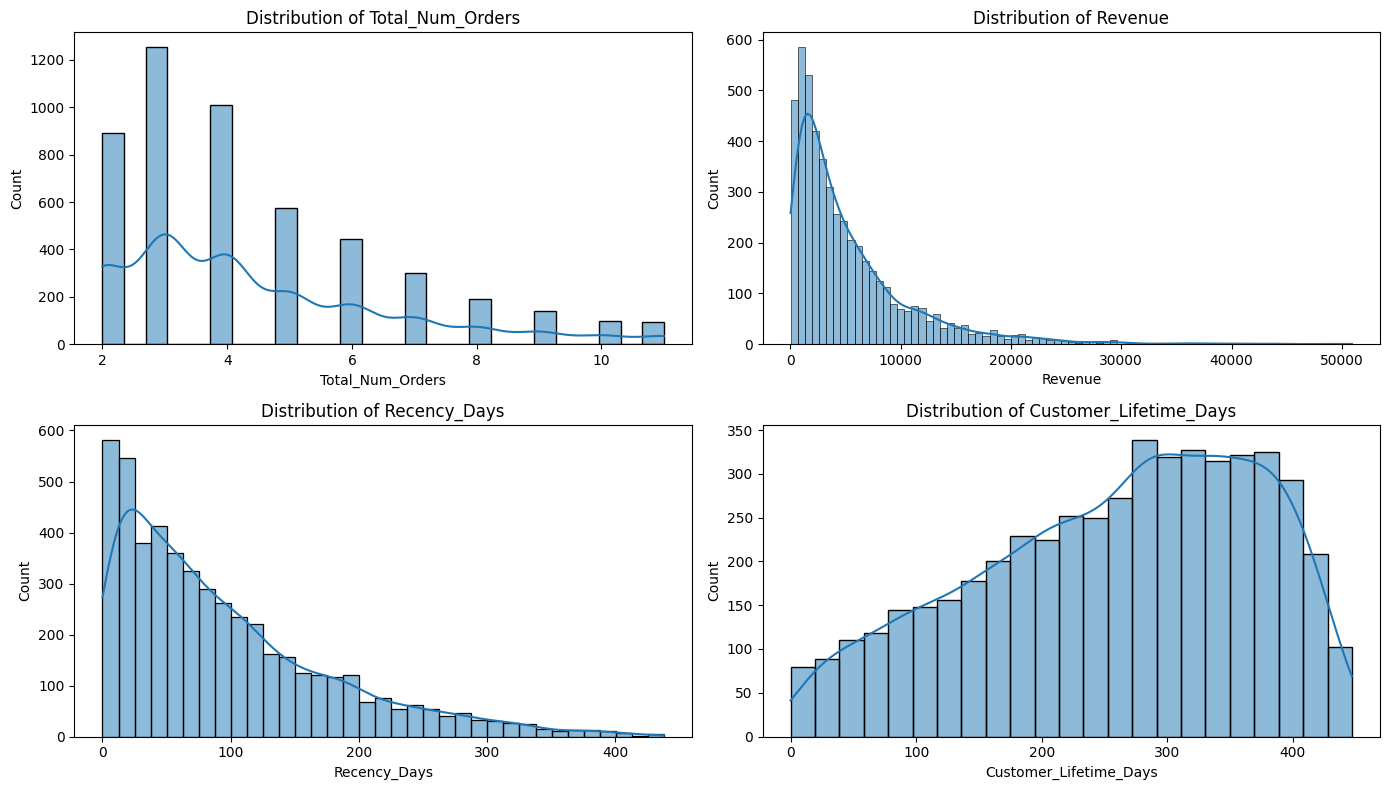

In [28]:
# Take the logarithm of skewed columns
customer_stats['Log_Revenue'] = np.log1p(customer_stats['Revenue'])
customer_stats['Log_AOV'] = np.log1p(customer_stats['AOV'])

#cols = ['Total_Num_Orders', 'Log_Revenue', 'Log_AOV', 'Recency_Days', 'Customer_Lifetime_Days', 'Avg_Customer_Rating']
cols = ['Total_Num_Orders', 'Revenue',  'Recency_Days', 'Customer_Lifetime_Days']
plot_histograms(customer_stats, cols, n_cols=2, kde=True, figsize_scale=4)

From the first plot, **total number of orders per customer**, it can be seen that the majority of customers purchase between 2 and 4 orders (3 orders being the peak value), while more than 5 orders are purchased less often by the customers. This means that many customers do buy more than once, but frequency still declines steadily.

From the **revenue** plot, as explored in the first notebook, it is obvious that most customers spend small–moderate amounts, while few customers spend very high amounts. The behaviour of AOV is similar. 

**Recency days** graph shows a monotonic decrease, which means that many customers purchased recently, while fewer customers are “old inactive” customers. Hence, there is not a large amount of inactive customers, and the churn over time is natural (customer decay curve). Since as number of day increases, the curve decreases with time in a nonlinear fashion, the recency days variable can potentially serve as a strong predictor variable later.

In the **Customer lifetime days** plot, it can be seen that many customers have shorter lifetimes, and the number of customers having up to 300 active days rises, and stays around this value to about 400 days, after which it declines. This means there’s a buildup of customers surviving up to 1 year, while not many survive long term (after 400 days for this dataset). 

From a business perspective, the main opportunity lies in increasing purchase frequency and extending customer lifetime beyond the 300–400 day range. Targeted engagement campaigns, loyalty incentives, and reactivation efforts focused on mid-tier customers could help shift customers toward higher frequency and longer retention, thereby increasing overall customer lifetime value without relying solely on high-spending  VIP customers.

Next, I want to see how do the top 20% of customers in terms of money spent behave, and how is this split depending on retention value.

In [29]:
# Check how much revenue comes from top 20% of spending customers
customer_stats_sorted = customer_stats.sort_values('Revenue', ascending=False)
top_20_percent_cutoff = int(len(customer_stats) * 0.2)
top_20_customers_revenue = customer_stats_sorted['Revenue'].iloc[:top_20_percent_cutoff].sum()
top_20_percent_customers = customer_stats_sorted.iloc[:top_20_percent_cutoff]
total_revenue = customer_stats['Revenue'].sum()

print(f"Top 20% of customers contribute {top_20_customers_revenue / total_revenue:.2%} of revenue")

Top 20% of customers contribute 53.61% of revenue


The fact that the top 20% of customers contribute 53.61% of revenue means that revenue is not heavily dependent on a tiny elite group, and the business is relatively balanced across customers.  In other words, the majority of the revenue doesn't depend only on VIPs, but is distributed across customers of various spending levels. This is good for the business because it indicates that it's important  both to retain top customers and to attract new ones.


Where analyzing how retention values are distributed across different variables, it was discovered that the number of average pages viewed and the average session duration was the same for retained and non-reatined customers.

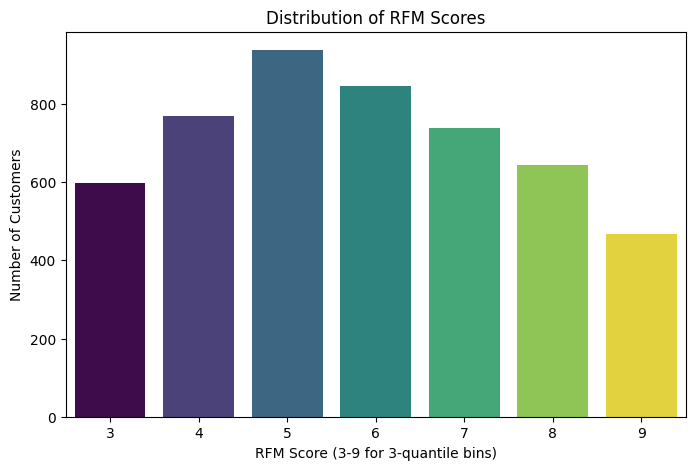

In [30]:
# Plot RFM Score counts
plt.figure(figsize=(8,5))
sns.countplot(x='RFM_Score', data=customer_stats, palette='viridis', hue='RFM_Score', legend=False)
plt.title('Distribution of RFM Scores')
plt.xlabel('RFM Score (3-9 for 3-quantile bins)')
plt.ylabel('Number of Customers')
plt.show()

In [31]:
customer_stats['RFM_Score'].value_counts().sort_index()

RFM_Score
3    597
4    769
5    938
6    847
7    739
8    643
9    467
Name: count, dtype: int64

From the countplot for the RFM score, it is apparent that counts peak at values 5 and 6, and decline when the values move towards 9 and also decline towards 3 and 4. This confirms the earlier findings that most customers add mid-value to the business, meaning they have average recency, frequency and amount spent, and the revenue is not dominated by VIPs. 

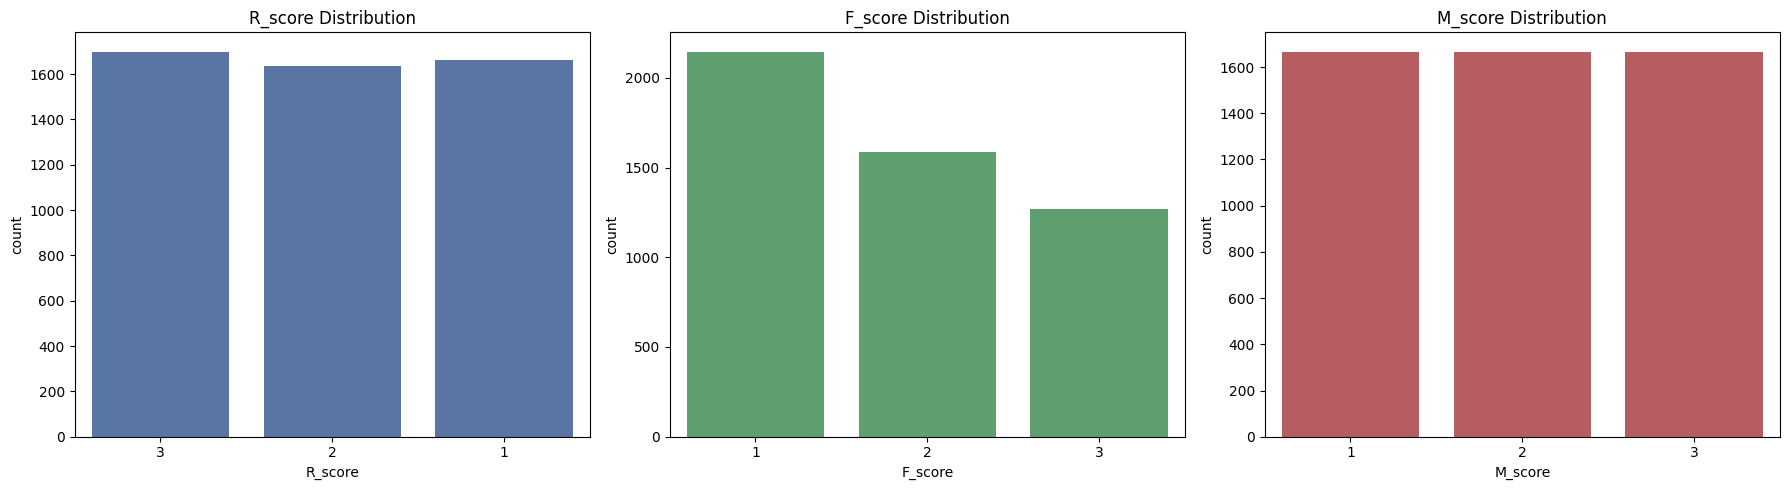

In [32]:
rfm_cols = ['R_score', 'F_score', 'M_score']
rfm_colors = ['#4c72b0', '#55a868', '#c44e52']  # one color per plot

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(rfm_cols):
    sns.countplot(x=col, data=customer_stats, ax=axes[i], color=rfm_colors[i])
    axes[i].set_title(f"{col} Distribution")

plt.tight_layout()
plt.show()

In [33]:
# Get individual value counts (concrete numbers for the graphs above)
rfm_distribution = pd.DataFrame({
    'R_score': customer_stats['R_score'].value_counts().sort_index(),
    'F_score': customer_stats['F_score'].value_counts().sort_index(),
    'M_score': customer_stats['M_score'].value_counts().sort_index()
})

rfm_distribution

,R_score,F_score,M_score
1,1664,2146,1667
2,1637,1584,1666
3,1699,1270,1667


Recency (R_score) and monetary value (M_score) are relatively evenly distributed across customers, suggesting that the business isn’t overly dependent on only recent buyers or big spenders. In contrast, frequency (F_score) is concentrated at lower levels, indicating that most customers purchase infrequently. This highlights repeat purchase behavior as the primary structural weakness of the customer base.

It’s important to keep in mind that frequency is part of how retention is defined (≥3 orders in six months). So the differences in F_score and overall RFM between retained and non-retained customers are expected — they don’t reveal new behavior on their own. Therefore, the strong differences in F_score and RFM metrics between retained and non-retained customers are expected and do not represent independent behavioral insights — they are a direct consequence of how retention is defined.

Even so, RFM is still useful. While F_score doesn’t give independent insight into retention, it helps with segmenting customers and deciding where to focus marketing efforts. Think of it as a strategic tool to spot which groups to target rather than a predictor of retention itself.

Strategically, the most actionable opportunity lies in shifting low- and mid-frequency customers toward higher purchase frequency. In particular, nurturing mid-tier segments (e.g., RFM 5–6) into higher-value groups (RFM 7–8) could meaningfully increase lifetime value and overall revenue.

In order to analyze the data for retained vs non retained customers (such as average session duration, average number of pages viewed etc.) I need a first to merge retention values to the original ecommerce dataset, and then compute averages depending on the value in retention column for each row.

In [34]:
customer_stats['R_score'] = customer_stats['R_score'].astype(int)
customer_stats['F_score'] = customer_stats['F_score'].astype(int)
customer_stats['M_score'] = customer_stats['M_score'].astype(int)


retention_comparison = customer_stats.groupby('Retention').agg(
    
    # Business Metrics
    Avg_Num_Orders=('Total_Num_Orders','mean'),
    Avg_Revenue=('Revenue','mean'),
    Avg_AOV=('AOV','mean'),
    
    # Engagement Metrics
    Avg_Session_Duration_Minutes=('Avg_Session_Duration_Minutes','mean'),
    Avg_Pages_Viewed=('Avg_Pages_Viewed','mean'),
    Avg_Customer_Rating=('Avg_Customer_Rating','mean'),
    Avg_Delivery_Time_Days=('Avg_Delivery_Time_Days','mean'),
    
    # Lifecycle Metrics
    Avg_Recency_Days=('Recency_Days','mean'),
    Avg_Customer_Lifetime_Days=('Customer_Lifetime_Days','mean'),
    
    # Discount Sensitivity
    Avg_Discount_Rate=('Avg_Discount_Rate','mean'),
    
    # RFM Metrics 
    Avg_R_score=('R_score','mean'),
    Avg_F_score=('F_score','mean'),
    Avg_M_score=('M_score','mean'),
    Avg_RFM_Score=('RFM_Score','mean'),
    
    # Demographics
    Avg_Age=('Age','mean'),

    # Returning behavior consistency check
    Returning_Rate=('Is_Returning_Customer','mean'),
    
    # Sample size
    Num_Customers=('Customer_ID','count')

).round(2).reset_index()

retention_comparison

,Retention,Avg_Num_Orders,Avg_Revenue,Avg_AOV,Avg_Session_Duration_Minutes,Avg_Pages_Viewed,Avg_Customer_Rating,Avg_Delivery_Time_Days,Avg_Recency_Days,Avg_Customer_Lifetime_Days,Avg_Discount_Rate,Avg_R_score,Avg_F_score,Avg_M_score,Avg_RFM_Score,Avg_Age,Returning_Rate,Num_Customers
0,0,3.27,3900.27,1170.42,14.62,8.99,3.91,6.49,95.39,255.53,0.04,1.99,1.41,1.76,5.17,35.12,0.86,2545
1,1,5.59,6830.31,1205.74,14.52,9.00,3.89,6.52,94.30,260.68,0.05,2.02,2.25,2.25,6.52,34.94,1.00,2455


Retained customers place substantially more orders (5.59 vs. 3.27) and consequently generate significantly higher total revenue (~6,830 vs. ~3,900). Since retention is explicitly defined based on purchase frequency, this difference is expected and internally consistent with the definition.

Importantly, Average Order Value (AOV) is very similar across both groups, indicating that retained customers do not spend more per transaction — they simply purchase more often. Revenue differences are therefore volume-driven rather than basket-size-driven.

Engagement metrics (session duration and pages viewed) are nearly identical, suggesting that browsing behavior does not meaningfully distinguish retained from non-retained customers. Similarly, customer ratings and delivery times show minimal variation, indicating that satisfaction and operational performance are unlikely to be primary drivers of retention in this dataset.

Recency and customer lifetime metrics are also closely aligned between groups. This implies that retained customers are not necessarily more recent or longer-active customers on average — retention here reflects frequency intensity rather than tenure.

RFM differences are largely driven by the frequency component, which is mechanically embedded in the retention definition. As such, higher F_score and RFM_Score among retained customers are expected and do not constitute independent explanatory insight.

Interestingly, even 86% of non-retained customers are marked as returning customers, meaning that many customers make repeat purchases but still do not meet the ≥3 order retention threshold. This suggests that the behavioral gap is not between “one-time vs repeat” buyers, but rather between low-frequency and high-frequency repeat buyers.

Overall, the only strong structural differentiator is purchase frequency — which is consistent with how retention is defined. The results therefore demonstrate internal validity, but they also indicate that retention in this framework is primarily a function of order volume rather than engagement, satisfaction, or tenure.

In the cell below, I will create a function that returns a dataframe representing a retention summary function.

In [35]:
bins = [-0.01, 0, 0.10, 0.20, 0.30]
labels = ['No Discount', '0-10%', '10-20%', '20-30%']

customer_stats['Discount_Bucket'] = pd.cut(
    customer_stats['Avg_Discount_Rate'],
    bins=bins,
    labels=labels
)

# Create a retention summary function
def retention_summary(df, group_col):
    """"
    Summarizes retention by a given category.

    Parameters
    ----------
    df : pd.DataFrame
        Customer-level data with 'Customer_ID' and 'Retention' columns.
    group_col : str
        Column to group by (e.g., City, Device, Payment, Discount_Bucket).

    Returns
    -------
    pd.DataFrame
        Retention rate, number of customers, number of retained customers, 
        and share of retained customers for each group, sorted by retention rate.
    """
    
    total_customers = len(df)
    total_retained = df['Retention'].sum()
    
    summary = (df.groupby(group_col, observed=True)
            .agg(Retention_Rate=('Retention', 'mean'),
                Num_Customers=('Customer_ID', 'count'),
                Retained_Customers=('Retention', 'sum'))
            .reset_index())

    summary['Retained_Pct_Customers'] = summary['Retained_Customers'] / total_retained

    summary[['Retention_Rate', 'Retained_Pct_Customers']] = (
        summary[['Retention_Rate', 'Retained_Pct_Customers']]
        .round(2)
    )
    
    return summary.sort_values('Retention_Rate', ascending=False)

retention_by_city = retention_summary(customer_stats, 'City')
retention_by_payment = retention_summary(customer_stats, 'Most_Used_Payment')
retention_by_device = retention_summary(customer_stats, 'Most_Used_Device')
retention_by_discount = retention_summary(customer_stats, 'Discount_Bucket')

In [36]:
def plot_retention(data, x_col, title, rotation=0, hue=None):
    """
    Plots retention rates by category as a bar chart with customer counts.

    Parameters
    ----------
    data : pd.DataFrame
        Dataframe containing 'Retention_Rate' and 'Num_Customers' columns.
    x_col : str
        Column to use for the x-axis (e.g., City, Device, Payment, Discount_Bucket).
    title : str
        Title of the plot.
    rotation : int, default 0
        Rotation angle for x-axis labels.
    hue : str, optional
        Column to group bars by color (e.g., another categorical variable).

    Returns
    -------
    None
        Displays a bar plot showing retention rates and annotates number of customers above each bar.
    """
    
    plt.figure(figsize=(8,5))
    
    ax = sns.barplot(
        data=data,
        x=x_col,
        y='Retention_Rate',
        palette='viridis',
        hue=hue
    )
    
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel('Retention Rate')
    plt.ylim(0, 1)
    plt.xticks(rotation=rotation)
    
    # Annotate with number of customers (small text above bars)
    for i, row in data.iterrows():
        ax.text(
            i,
            row['Retention_Rate'] + 0.02,
            f"n={row['Num_Customers']}",   # n is the number of customers in this category
            ha='center'
        )
    
    plt.tight_layout()
    plt.show()

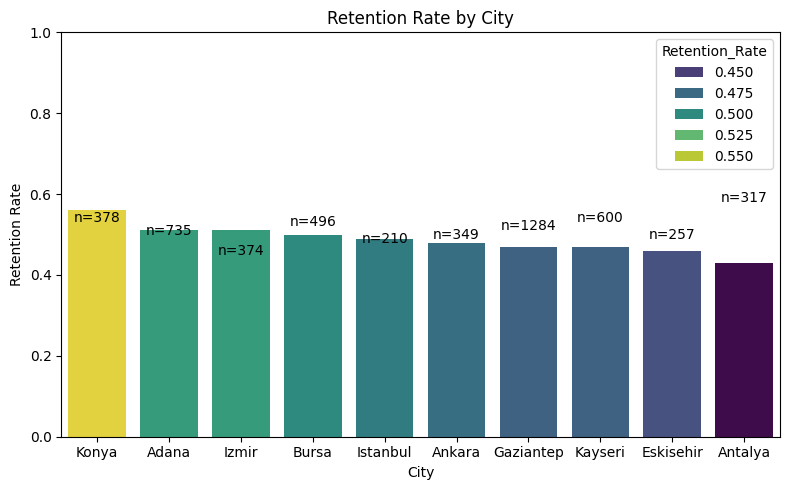

,City,Retention_Rate,Num_Customers,Retained_Customers,Retained_Pct_Customers
9,Konya,0.56,317,177,0.07
0,Adana,0.51,378,193,0.08
7,Izmir,0.51,600,308,0.13
3,Bursa,0.50,496,248,0.10
6,Istanbul,0.49,1284,629,0.26
1,Ankara,0.48,735,356,0.15
5,Gaziantep,0.47,349,164,0.07
8,Kayseri,0.47,257,122,0.05
4,Eskisehir,0.46,210,96,0.04
2,Antalya,0.43,374,162,0.07


In [37]:
plot_retention(retention_by_city, 'City', 'Retention Rate by City', hue='Retention_Rate')
retention_by_city

Smaller cities like Konya and Adana have the highest retention rates (around 51–56%), but they don’t contribute much to overall revenue because they have fewer customers (only 7–8% of retained customers). On the other hand, bigger cities like Istanbul and Ankara have slightly lower retention (48–49%) but account for the largest share of retained customers (26% and 15%), making them much more important for the business. In short, while retention rate shows how loyal a city’s customers are, the actual business impact comes from the number of customers. Therefore, focusing on high-volume cities will have the biggest effect.

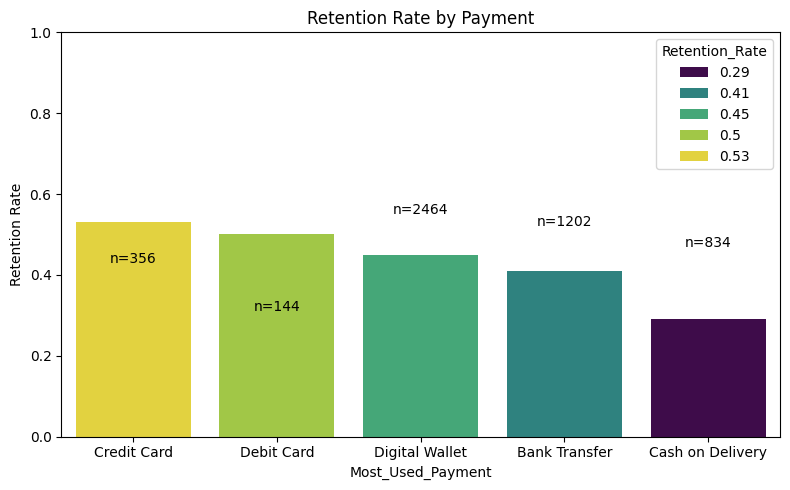

,Most_Used_Payment,Retention_Rate,Num_Customers,Retained_Customers,Retained_Pct_Customers
2,Credit Card,0.53,2464,1297,0.53
3,Debit Card,0.50,1202,596,0.24
4,Digital Wallet,0.45,834,373,0.15
0,Bank Transfer,0.41,356,147,0.06
1,Cash on Delivery,0.29,144,42,0.02


In [38]:
plot_retention(retention_by_payment, 'Most_Used_Payment', 'Retention Rate by Payment', hue='Retention_Rate')
retention_by_payment

Customers paying with Credit Cards have the highest retention rate (53%) and also make up the largest segment (2,464 customers), making them the most valuable and strategically important group. Debit card users retain at 50% (1,202 customers) and digital wallet users at 45% (834 customers), forming mid-sized, moderately loyal groups. Bank transfer (41%, 356 customers) and cash on delivery (29%, 144 customers) have both lower retention and smaller numbers, which could suggest these payment methods are less convenient or less preferred by customers.


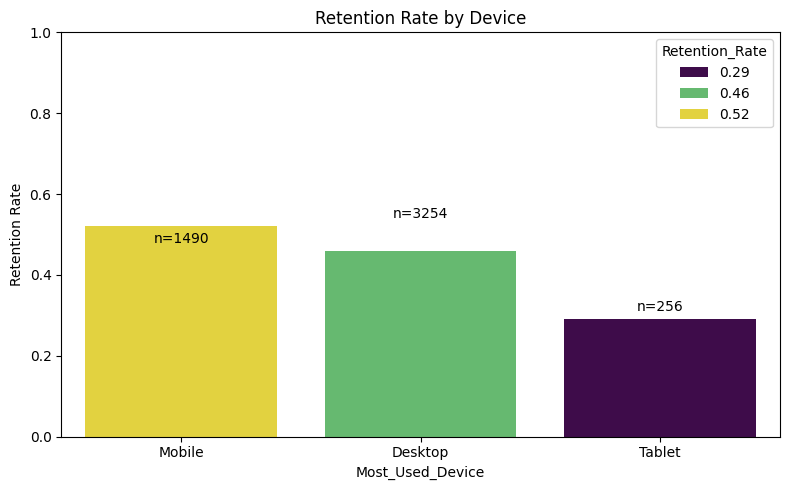

,Most_Used_Device,Retention_Rate,Num_Customers,Retained_Customers,Retained_Pct_Customers
1,Mobile,0.52,3254,1698,0.69
0,Desktop,0.46,1490,683,0.28
2,Tablet,0.29,256,74,0.03


In [39]:
plot_retention(retention_by_device, 'Most_Used_Device', 'Retention Rate by Device', hue='Retention_Rate')
retention_by_device

Mobile users have the highest retention rate (52%) and make up the largest group (3,254 customers), making them the most important segment to focus on. Desktop users have moderate retention (46%, 1,490 customers), while tablet users have the lowest retention (29%, 256 customers) and are a small group, so they have less overall impact.

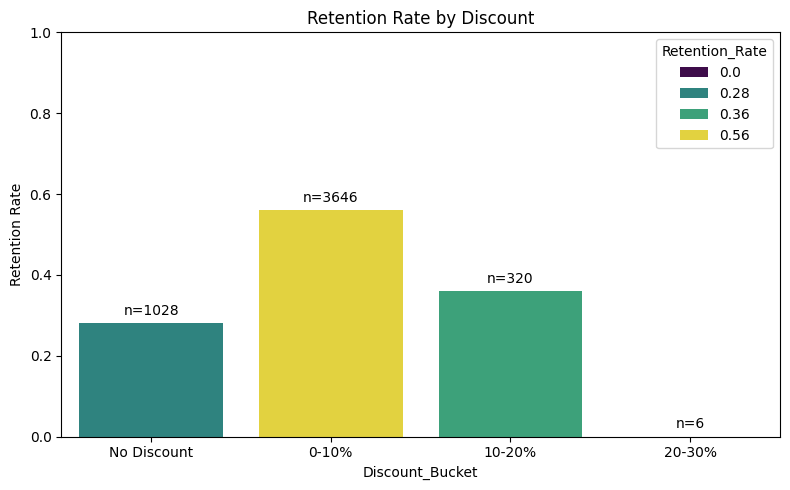

,Discount_Bucket,Retention_Rate,Num_Customers,Retained_Customers,Retained_Pct_Customers
1,0-10%,0.56,3646,2052,0.84
2,10-20%,0.36,320,116,0.05
0,No Discount,0.28,1028,287,0.12
3,20-30%,0.00,6,0,0.00


In [40]:
plot_retention(retention_by_discount, 'Discount_Bucket', 'Retention Rate by Discount', hue='Retention_Rate')
retention_by_discount

Customers receiving small discounts (0–10%) have the highest retention rate (56%) and make up the largest segment (3,646 customers), accounting for 84% of retained customers. Moderate discounts (10–20%) show lower retention (36%) despite a smaller segment (320 customers), while no-discount customers have low retention (28%). Very high discounts (20–30%) have no retained customers, but this group is extremely small (6 customers), so the impact is negligible.

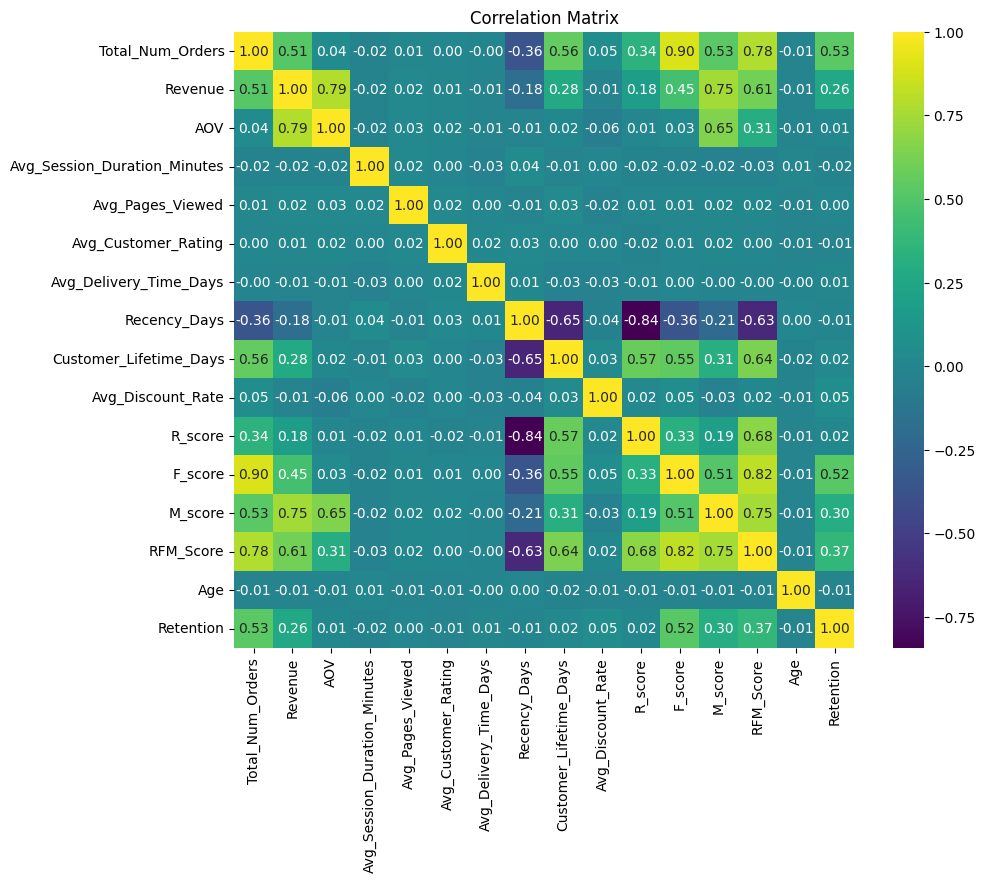

In [41]:
plt.figure(figsize=(10,8))
numeric_cols = ['Total_Num_Orders','Revenue','AOV','Avg_Session_Duration_Minutes','Avg_Pages_Viewed','Avg_Customer_Rating','Avg_Delivery_Time_Days','Recency_Days','Customer_Lifetime_Days','Avg_Discount_Rate','R_score','F_score','M_score','RFM_Score','Age','Retention']
sns.heatmap(customer_stats[numeric_cols].corr(), annot=True, fmt=".2f", cmap='viridis')
plt.title('Correlation Matrix')
plt.show()

Looking at the correlation matrix, the strongest positive relationships with Retention are F_score (0.52), Total_Num_Orders (0.53), and RFM_Score (0.37), which makes sense since retention is frequency-based. Revenue (0.26) and M_score (0.30) show moderate positive correlations, while AOV, engagement metrics (pages, session duration), ratings, delivery time, and age have almost no correlation with retention. Recency (-0.01) and Customer Lifetime (0.02) are essentially uncorrelated.

In short: retention is primarily driven by frequency and RFM-related metrics, not by spending per order, browsing behavior, or demographics. This confirms earlier insights that loyalty initiatives should focus on increasing repeat purchases rather than improving engagement or satisfaction metrics alone.

## Key Takeaways

#### **Transaction level insights**

* Revenue is volume-driven (depends on the number of orders), not AOV-driven. This means that customers who buy more often drive most of the revenue, not necessarily those who spend more per order.

* Electronics is the primary revenue driver. While numbers of orders are relatively balanced across categories, electronics brings in a bigger share of revenue due to higher unit prices.

* Revenue concentration is moderate, not extreme. The top 20% of customers contribute about 53.6% of total revenue, indicating a relatively balanced customer base rather than heavy dependence on a small VIP customer segment.

* Small (0–10%) to moderate (10%-20%) discounts  correlate with stronger performance. Customers receiving these discounts tend to come back more often, while bigger discounts don’t seem to improve retention much. Very high discounts (20–30%) have very few orders (6 customers), so their impact on retention is negligible and can’t be meaningfully interpreted.


* Mobile dominates transaction share. Most purchases are done on mobile devices, which is why focusing on mobile optimization is strategically important for the business.


#### **Customer level insights**:

* Retention is frequency-driven, meaning that retention mainly comes from customers who buy often. This aligns with the chosen retention definition that customers who make 3 or more purchases within six months are the ones who stick around, showing that repeat buying is the strongest signal.

* Buying recently doesn’t always mean that a customer is loyal. Frequency matters more than recency alone, which means that just because a customer made a purchase recently, doesn't mean he will keep purchasing in the future.

* Mid-tier customers are the biggest growth opportunity. Those with moderate RFM scores (like 5–6) have the most potential to become repeat buyers, so don’t focus only on the top spenders.

* High revenue customers are not always the most loyal. Making expensive purchases and being a loyal customer are correlated, but  high revenue doesn't guarantee repeat purchases. 

* Engagement metrics, like session duration and pages viewed, have less impact on retention compared to how often people actually buy.

## Next Steps

* **Feature selection**: Identify and select key features for retention modeling based on EDA insights.

* **Feature engineering**: Generate new features to improve predictive power.

* **Splitting the data**: Split the customer-level dataset into training and test sets for modeling.

* **Choosing a model**: Apply predictive modeling techniques to forecast retention and evaluate model performance.
